# EDA

In [8]:
# Import Modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import kagglehub

### **Load Data**

In [3]:
# Download data if it isn't downloaded already

if not Path("books_db/ratings.csv").exists():
    kagglehub.dataset_download("zygmunt/goodbooks-10k", output_dir="books_db")
else:
    print("File already exists")

File already exists


In [5]:
# Create Dataframes
file_path = "books_db"

ratings_df = pd.read_csv(f"{file_path}/ratings.csv")
books_df = pd.read_csv(f"{file_path}/books.csv")
display(ratings_df.head())
display(ratings_df.shape)
display(books_df.head())
display(books_df.shape)

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


(981756, 3)

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


(10000, 23)

### **Data Overview & Descriptive Statistics**

In [6]:
# Users
display(ratings_df.head())
print(f"Shape: {ratings_df.shape}")
print(f"Duplicate Rows: {ratings_df.duplicated().sum()}")
missing_values_ratings = ratings_df.isnull().sum().to_frame(name="Missing Values: Ratings")
display(missing_values_ratings)

,book_id,user_id,rating
0,1,314,5
1,1,439,3
2,1,588,5
3,1,1169,4
4,1,1185,4


Shape: (981756, 3)
Duplicate Rows: 1644


,Missing Values: Ratings
book_id,0
user_id,0
rating,0


In [7]:
# Movies
display(books_df.head())
print(f"Shape: {books_df.shape}")
print(f"Duplicate Rows: {books_df.duplicated().sum()}")
missing_values_books = books_df.isnull().sum().to_frame(name="Missing Values: Books")
display(missing_values_books)

,id,book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


Shape: (10000, 23)
Duplicate Rows: 0


,Missing Values: Books
id,0
book_id,0
best_book_id,0
work_id,0
books_count,0
isbn,700
isbn13,585
authors,0
original_publication_year,21
original_title,585


In [28]:
# get the total pool of books and check min and max ID
all_unique_books = pd.concat([books_df['book_id'], ratings_df['book_id']]).unique()
all_books_pool = np.array(all_unique_books)
print(f"Total unique books in the pool: {len(all_books_pool)}")

print("Contains missing?", pd.isna(all_books_pool).any())

print("Min ID:", np.nanmin(all_books_pool))
print("Max ID:", np.nanmax(all_books_pool))
print("Total unique books in the pool:", len(all_books_pool))

Total unique books in the pool: 19188
Contains missing? False
Min ID: 1
Max ID: 33288638
Total unique books in the pool: 19188


### **Sparsity**

In [15]:
# Ratings Sparsity
total_users = ratings_df['user_id'].nunique()
total_books = len(all_unique_books)

total_possible = total_users * total_books

total_ratings = len(ratings_df[['user_id', 'book_id']].drop_duplicates())

ratings_sparsity_percentage = ((total_possible - total_ratings) / total_possible) * 100

print(f"Total Users: {total_users}")
print(f"Total Books: {total_books}")
print(f"Total Possible: {total_possible}")
print(f"Total Reviews: {total_ratings}")
print(f"Sparsity: {ratings_sparsity_percentage}")

Total Users: 53424
Total Books: 19188
Total Possible: 1025099712
Total Reviews: 979478
Sparsity: 99.90445046579039


### **Visualization**

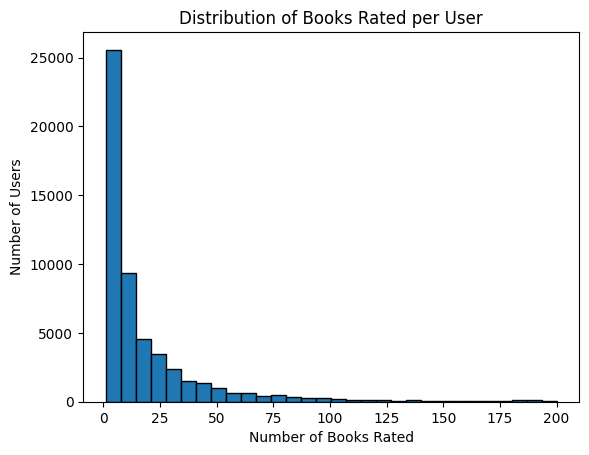

In [18]:
# User Activity (Ratings)
user_rating_counts = ratings_df.groupby('user_id')['book_id'].nunique()

plt.hist(user_rating_counts, bins=30, edgecolor='black')
plt.title('Distribution of Books Rated per User')
plt.xlabel('Number of Books Rated')
plt.ylabel('Number of Users')
plt.show()

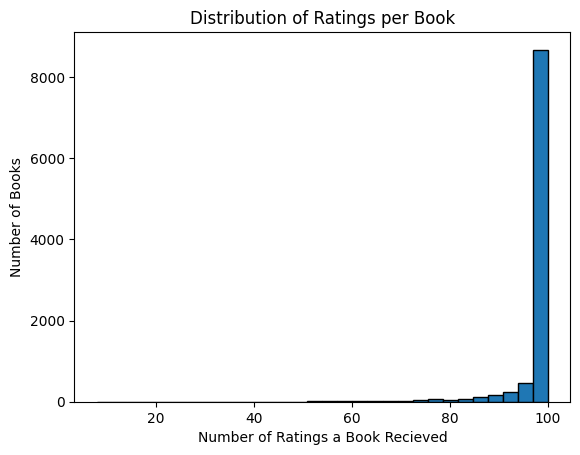

In [21]:
# Book Popularity (Ratings)
book_popularity_reviews = ratings_df.groupby('book_id')['user_id'].nunique()
plt.hist(book_popularity_reviews, bins=30, edgecolor='black')
plt.title('Distribution of Ratings per Book')
plt.xlabel('Number of Ratings a Book Recieved')
plt.ylabel('Number of Books')
plt.show()

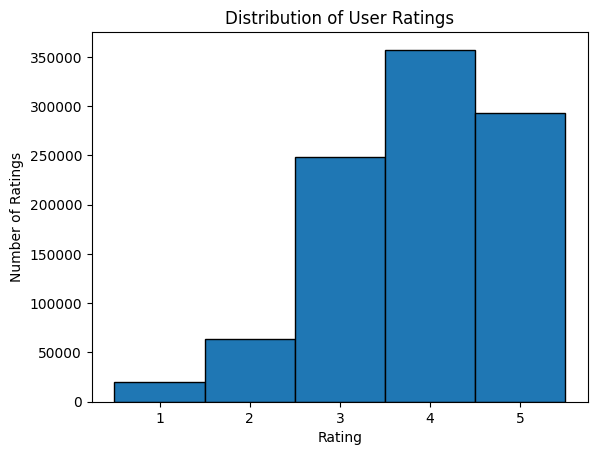

In [24]:
# Rating Distribution
plt.hist(ratings_df['rating'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5], edgecolor='black')

plt.title('Distribution of User Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')

plt.show()

In [22]:
# Check how many books each user rated
books_rated_counts = ratings_df['user_id'].value_counts()
books_rated_counts

user_id
12874    200
30944    200
28158    199
52036    199
12381    199
        ... 
47248      2
48186      2
17867      2
11638      2
43877      2
Name: count, Length: 53424, dtype: int64

In [23]:
books_rated_distribution = books_rated_counts.value_counts().sort_index()
books_rated_distribution

count
2      8302
3      5436
4      3976
5      3212
6      2471
       ... 
195       5
196       7
197       3
199       3
200       2
Name: count, Length: 198, dtype: int64

In [27]:
users_below_10 = (books_rated_counts < 10).sum()

print(f"Number of users who rated less than 10 books: {users_below_10}")

Number of users who rated less than 10 books: 29019
